# Packages

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import warnings

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score

from sklearn.model_selection import learning_curve

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Analysis and organization

In [21]:
# Carregar o arquivo
df = pd.read_csv('/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/data/dados_quantum_walk_T_100_data_2500_2.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.00014,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.000210,16.048081,0.0,2.138640e-13,0.0,2.283547e-10,0.0,5.044412e-08,0.0,0.000004,...,0.00014,0.0,0.000004,0.0,5.044412e-08,0.0,2.283547e-10,0.0,2.138640e-13,0.0
2,0.000419,16.041934,0.0,2.132919e-13,0.0,2.278022e-10,0.0,5.033576e-08,0.0,0.000004,...,0.00014,0.0,0.000004,0.0,5.033576e-08,0.0,2.278022e-10,0.0,2.132919e-13,0.0
3,0.000629,16.055498,0.0,2.145796e-13,0.0,2.290560e-10,0.0,5.058426e-08,0.0,0.000004,...,0.00014,0.0,0.000004,0.0,5.058426e-08,0.0,2.290560e-10,0.0,2.145796e-13,0.0
4,0.000838,16.030456,0.0,2.144153e-13,0.0,2.289119e-10,0.0,5.055973e-08,0.0,0.000004,...,0.00014,0.0,0.000004,0.0,5.055973e-08,0.0,2.289119e-10,0.0,2.144153e-13,0.0


In [22]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.00014,...,0.00014,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.138640e-13,0.0,2.283547e-10,0.0,5.044412e-08,0.0,0.000004,0.0,0.00014,...,0.00014,0.0,0.000004,0.0,5.044412e-08,0.0,2.283547e-10,0.0,2.138640e-13,0.0
2,0.0,2.132919e-13,0.0,2.278022e-10,0.0,5.033576e-08,0.0,0.000004,0.0,0.00014,...,0.00014,0.0,0.000004,0.0,5.033576e-08,0.0,2.278022e-10,0.0,2.132919e-13,0.0
3,0.0,2.145796e-13,0.0,2.290560e-10,0.0,5.058426e-08,0.0,0.000004,0.0,0.00014,...,0.00014,0.0,0.000004,0.0,5.058426e-08,0.0,2.290560e-10,0.0,2.145796e-13,0.0
4,0.0,2.144153e-13,0.0,2.289119e-10,0.0,5.055973e-08,0.0,0.000004,0.0,0.00014,...,0.00014,0.0,0.000004,0.0,5.055973e-08,0.0,2.289119e-10,0.0,2.144153e-13,0.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


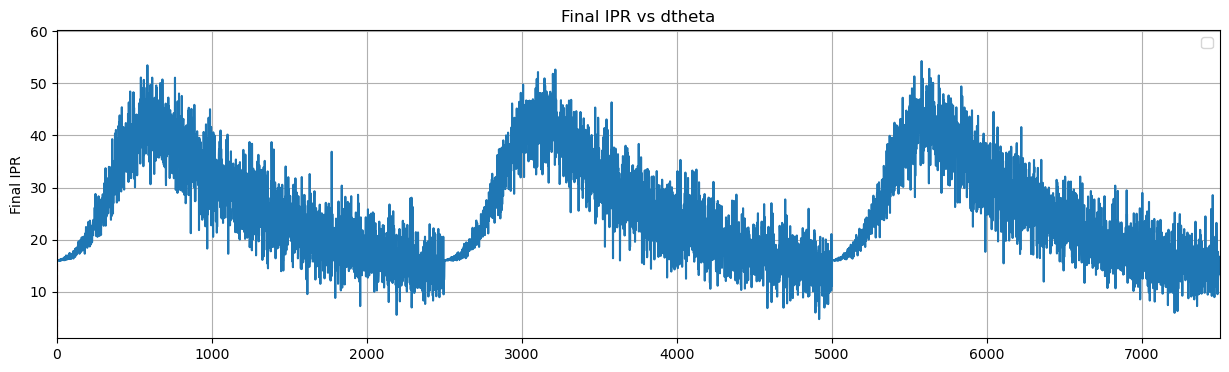

In [23]:
IPR_list = df['IPR'].values

plt.figure(figsize=(15,4))
plt.plot(df['IPR'].values)
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.xlim(0, 7500)
plt.legend()
plt.grid(True)
plt.show()

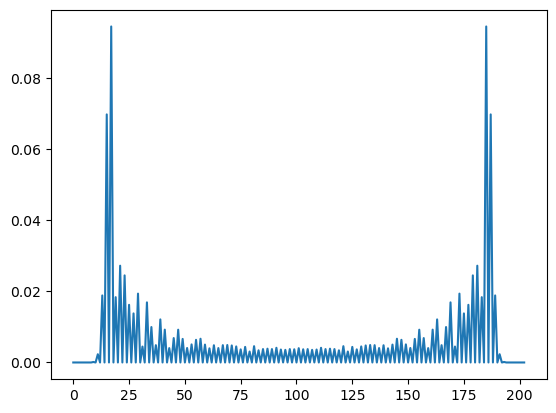

In [24]:
plt.plot(df_probs.iloc[25].values)
plt.show()

List of IPR

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


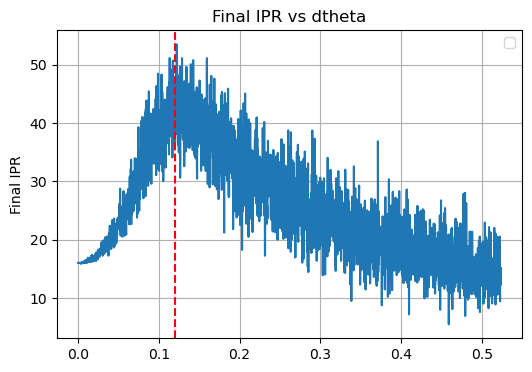

In [25]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

0.120266385431542

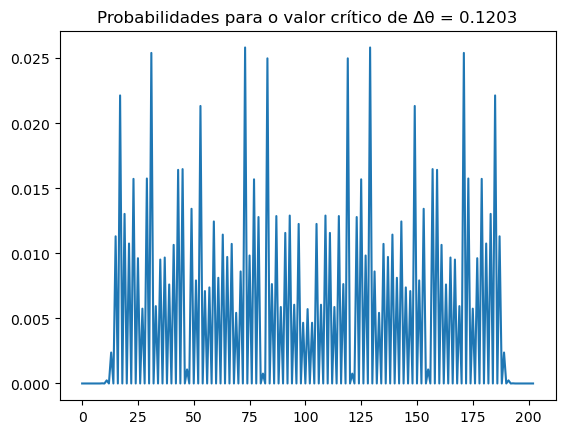

In [27]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [28]:
# --- Configurações de Limites ---
limite = 2500
tamanho_total = 250000
tamanho_bloco = 2500

# --- Processamento do Bloco Inicial ---
# n_total será 2500
n_total = len(df.iloc[:limite])

# Localiza o ponto de transição dentro das primeiras 2500 linhas
ponto_de_corte = np.argmax(df['IPR'].values[:limite])

# Cria o bloco base: parte 0, parte 1 (Isso já gera um array NumPy)
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# --- Repetição para as 250.000 linhas ---
repeticoes = tamanho_total // tamanho_bloco

# CORREÇÃO AQUI: Removido o .values, pois coluna_rotulo já é um array
labels_repetidos = np.tile(coluna_rotulo, repeticoes)

# Se o seu df_probs tiver um tamanho exato de 250.000, isso funcionará:
df_probs['label'] = labels_repetidos.astype(int)

/tmp/ipykernel_11706/3642666967.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_probs['label'] = labels_repetidos.astype(int)


Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [29]:
df_training = df_probs.iloc[np.r_[0:300, -300:-1]]

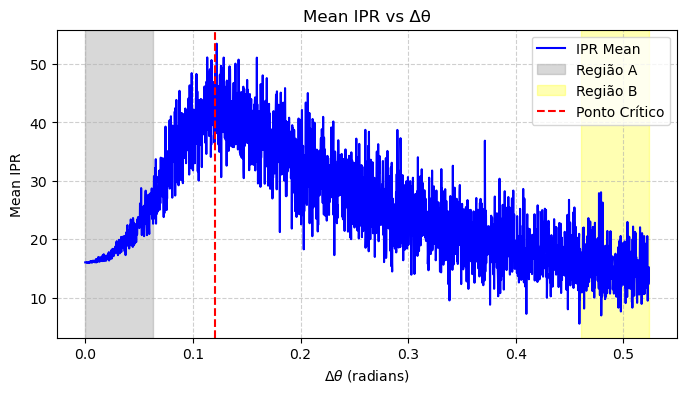

In [30]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500], label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:2500][0], df['delta_theta'].values[:2500][300], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:2500][-300], df['delta_theta'].values[:2500][-1], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

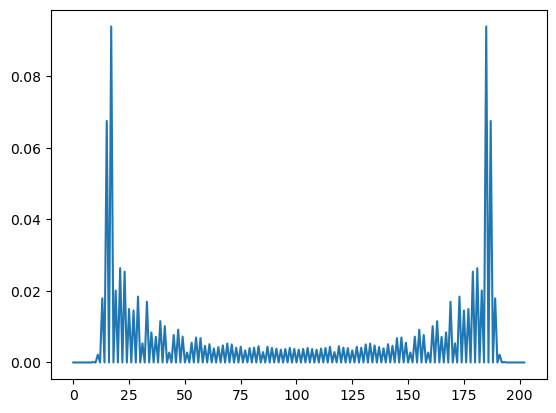

In [31]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [32]:
len(df_probs.iloc[49].values)

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [33]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

In [34]:
df_train.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202,label
110,0.0,2.159037e-13,0.0,2.300938e-10,0.0,5.071405e-08,0.0,4.012124e-06,0.0,1.396442e-04,...,0.0,4.012124e-06,0.0,5.071405e-08,0.0,2.300938e-10,0.0,2.159037e-13,0.0,0
249819,0.0,1.046049e-25,0.0,3.004311e-22,0.0,1.670556e-19,0.0,3.102433e-17,0.0,2.335009e-15,...,0.0,3.102433e-17,0.0,1.670556e-19,0.0,3.004311e-22,0.0,1.046049e-25,0.0,1
249964,0.0,3.554055e-31,0.0,2.547907e-27,0.0,3.657263e-24,0.0,1.819663e-21,0.0,3.828554e-19,...,0.0,1.819663e-21,0.0,3.657263e-24,0.0,2.547907e-27,0.0,3.554055e-31,0.0,1
77,0.0,2.267618e-13,0.0,2.406290e-10,0.0,5.280696e-08,0.0,4.159533e-06,0.0,1.441440e-04,...,0.0,4.159533e-06,0.0,5.280696e-08,0.0,2.406290e-10,0.0,2.267618e-13,0.0,0
181,0.0,2.403027e-13,0.0,2.526324e-10,0.0,5.484119e-08,0.0,4.264545e-06,0.0,1.455058e-04,...,0.0,4.264545e-06,0.0,5.484119e-08,0.0,2.526324e-10,0.0,2.403027e-13,0.0,0


# Checking the accuracy

In [35]:
X_train = df_train.drop(columns=['label']).values
y_train = df_train['label'].values

X_test = df_test.drop(columns=['label']).values
y_test = df_test['label'].values

In [36]:
clf = SGDClassifier(
            loss='modified_huber', 
            penalty='l2', 
            alpha=0.00001,
            max_iter=10000, 
            tol=1e-5, 
            learning_rate='optimal',
            early_stopping=True,
            n_iter_no_change=10000
            
        )

## Acurácia Treino e teste

In [37]:
# 1. Treinar
clf.fit(X_train, y_train)

# 2. Predizer nos dois conjuntos
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# 3. Calcular Acurácias
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia Treino: {acc_train:.4f}")
print(f"Acurácia Teste: {acc_test:.4f}")
print(f"Gap (Decoração): {acc_train - acc_test:.4f}")

Acurácia Treino: 1.0000
Acurácia Teste: 1.0000
Gap (Decoração): 0.0000


/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


## Curva de Aprendizado

### First figure

/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum

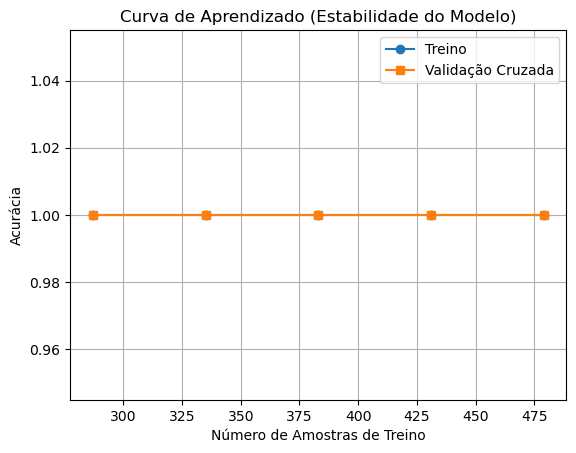

In [38]:
X_train2 = df_training.drop(columns=['label']).values
y_train2 = df_training['label'].values

warnings.filterwarnings("ignore", category=FutureWarning)

# O learning_curve treina o modelo em subconjuntos de tamanhos diferentes
train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train2, y_train2, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# Médias e Desvios
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label="Treino", marker='o')
plt.plot(train_sizes, test_mean, label="Validação Cruzada", marker='s')
plt.title("Curva de Aprendizado (Estabilidade do Modelo)")
plt.xlabel("Número de Amostras de Treino")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

### Second figure

/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:723: ConvergenceWarning: Maximum

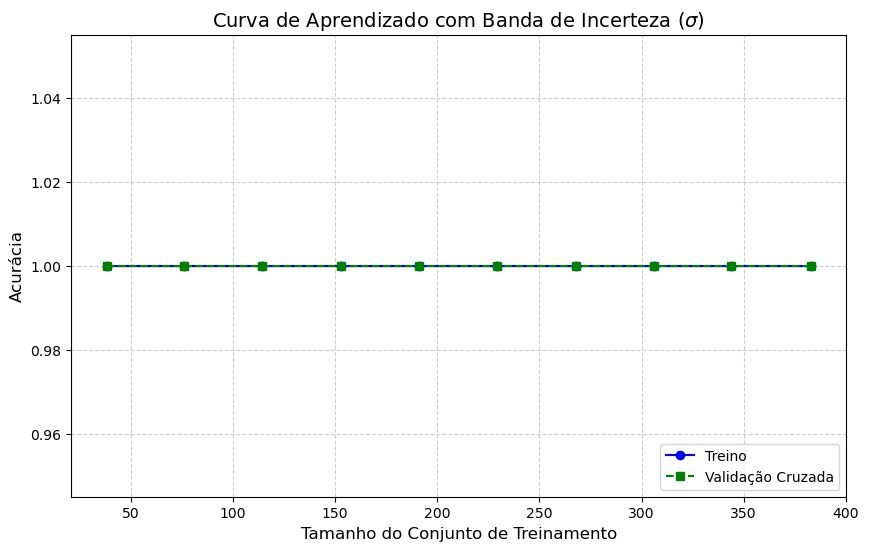

In [39]:
# 1. Gerar os dados (como você já fez)
train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train, y_train, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# 2. Calcular Média E Desvio Padrão
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1) # <--- O Desvio Padrão do Treino
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)   # <--- O Desvio Padrão do Teste (O mais importante!)

# 3. Plotagem Acadêmica
plt.figure(figsize=(10, 6))

# Linha do Treino com Sombreado
plt.plot(train_sizes, train_mean, color="blue", marker="o", label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")

# Linha do Teste com Sombreado
plt.plot(train_sizes, test_mean, color="green", marker="s", ls="--", label="Validação Cruzada")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color="green")

plt.title("Curva de Aprendizado com Banda de Incerteza " + r"($\sigma$)", fontsize=14)
plt.xlabel("Tamanho do Conjunto de Treinamento", fontsize=12)
plt.ylabel("Acurácia", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()